# 17 · Dependency-aware structured channel pruning

**Goal:** compare deterministic channel rankings, physically rebuild three multiples-of-eight channel schedules, and recover two explicit tracks with EMA-range QAT: the best quality-oriented diagnostic candidate and the best candidate satisfying the hard 2.5M-MAC deployment constraint.

## Why dependency propagation is mandatory

A removed pointwise output channel must also remove its BatchNorm entry, the matching channel of the next depthwise kernel, the corresponding input plane of the next pointwise kernel, and—at the final stage—the classifier row. Merely writing zeros leaves dense ESP-NN tensor shapes and latency unchanged.

`rank output channel → slice pointwise output → slice BatchNorm → slice next depthwise channel → slice next pointwise input → repeat`

In [10]:
import hashlib, json, subprocess, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display

from vww_esp32.config import load_config, seed_everything
from vww_esp32.evaluation import classification_metrics, collect_predictions, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite, run_tflite
from vww_esp32.modeling import build_tiny_mobilenet_v1, compile_model
from vww_esp32.preprocessing import make_dataset, representative_dataset, split_manifest
from vww_esp32.profiling import profile_model
from vww_esp32.pruning import NAMED_CHANNEL_SCHEDULES, STAGES, select_channel_indices, transfer_structured_weights
from vww_esp32.qat import build_qat_mobilenet_v1, copy_compatible_weights, copy_qat_weights_to_float

config, ROOT = load_config('configs/pruning.yaml')
seed = int(config['project']['seed']); seed_everything(seed)
IMAGE_SIZE = tuple(config['preprocessing']['image_size']); BATCH_SIZE = int(config['preprocessing']['batch_size'])
OUT = ROOT / 'artifacts/pruning/channel'
for child in ('models', 'reports', 'figures', 'logs'): (OUT / child).mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

## 1 · Load the frozen dataset and EMA-QAT pruning parent

The clean float graph recovered from EMA-QAT supplies both initialization tensors and deterministic importance signals. The original Fast-80 artifacts remain controls. Dataset splits and the held-out-test policy remain unchanged.

In [2]:
splits = split_manifest(pd.read_csv(ROOT / 'data/processed/manifest.csv'))
assert {key: len(value) for key, value in splits.items()} == {'train': 12000, 'val': 2000, 'test': 2000}
assert sum((~frame.image_path.map(lambda value: Path(value).exists())).sum() for frame in splits.values()) == 0
train_ds = make_dataset(splits['train'], IMAGE_SIZE, BATCH_SIZE, training=True, seed=seed)
val_ds = make_dataset(splits['val'], IMAGE_SIZE, BATCH_SIZE, training=False)
test_ds = make_dataset(splits['test'], IMAGE_SIZE, BATCH_SIZE, training=False)
parent = tf.keras.models.load_model(ROOT / config['reference']['float_model'])
parent_metrics = json.loads((ROOT / config['reference']['int8_metrics']).read_text())
_, _, parent_profile = profile_model(parent, training_batch_size=BATCH_SIZE)
parent_record = {'role': 'pruning_parent', 'source': config['reference']['float_model'], 'int8_source': config['reference']['int8_model'], 'accuracy': parent_metrics['accuracy'], 'recall': parent_metrics['recall'], 'f1': parent_metrics['f1'], 'pr_auc': parent_metrics['pr_auc']}
(OUT / 'reports/parent_record.json').write_text(json.dumps(parent_record, indent=2) + '\n')
print(f"EMA-QAT parent: {parent.count_params():,} params · {parent_profile['estimated_macs_batch1']:,} MACs")

EMA-QAT parent: 111,793 params · 3,993,536 MACs


## 2 · Compare channel-importance rules before training

We audit BatchNorm-gamma, pointwise-L1, and their normalized hybrid. Pairwise overlap exposes stages where rankings disagree and where a later sensitivity experiment deserves attention.

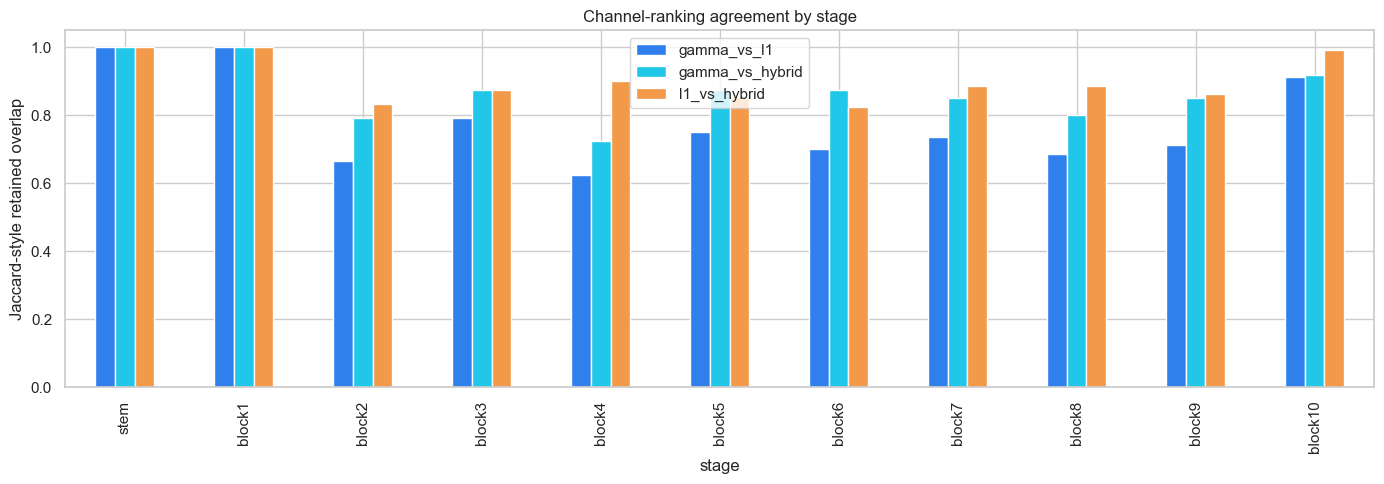

,stage,kept,gamma_vs_l1,gamma_vs_hybrid,l1_vs_hybrid
0,stem,8,1.000000,1.000000,1.000000
1,block1,16,1.000000,1.000000,1.000000
2,block2,24,0.666667,0.791667,0.833333
3,block3,24,0.791667,0.875000,0.875000
4,block4,40,0.625000,0.725000,0.900000
5,block5,48,0.750000,0.875000,0.854167
6,block6,80,0.700000,0.875000,0.825000
7,block7,80,0.737500,0.850000,0.887500
8,block8,80,0.687500,0.800000,0.887500
9,block9,80,0.712500,0.850000,0.862500


In [3]:
audit_schedule = NAMED_CHANNEL_SCHEDULES['aggressive']
rankings = {method: select_channel_indices(parent, audit_schedule, method) for method in config['channel_pruning']['ranking_methods']}
overlap_rows = []
for stage in STAGES:
    gamma, l1, hybrid = (set(rankings[key][stage]) for key in ('bn_gamma', 'pointwise_l1', 'hybrid'))
    target = len(gamma)
    overlap_rows.append({'stage': stage, 'kept': target, 'gamma_vs_l1': len(gamma & l1) / target, 'gamma_vs_hybrid': len(gamma & hybrid) / target, 'l1_vs_hybrid': len(l1 & hybrid) / target})
overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(OUT / 'reports/ranking_overlap.csv', index=False)
fig, ax = plt.subplots(figsize=(14, 5)); overlap.set_index('stage').drop(columns='kept').plot(kind='bar', ax=ax, color=['#2F80ED', '#21C7E8', '#F2994A']); ax.set(title='Channel-ranking agreement by stage', ylabel='Jaccard-style retained overlap', ylim=(0, 1.05)); fig.tight_layout(); fig.savefig(OUT / 'figures/ranking_overlap.png', dpi=170, bbox_inches='tight'); plt.show()
display(overlap)

## 3 · Build physical channel schedules and verify savings

The first screen fixes the inexpensive, auditable BatchNorm-gamma ranking while varying topology. Counts remain multiples of eight for ESP-NN alignment. Every tensor axis is checked by the transfer utility.

,candidate,schedule,parameters,macs,mac_reduction_pct,peak_live_int8
0,moderate_a,8-16-24-24-48-48-104-104-104-104-208,74801,2824320,29.277713,51200
1,moderate_b,8-16-24-32-48-64-96-96-96-96-192,69081,2901056,27.356208,51200
2,aggressive,8-16-24-24-40-48-80-80-80-80-160,48985,2301840,42.360855,51200


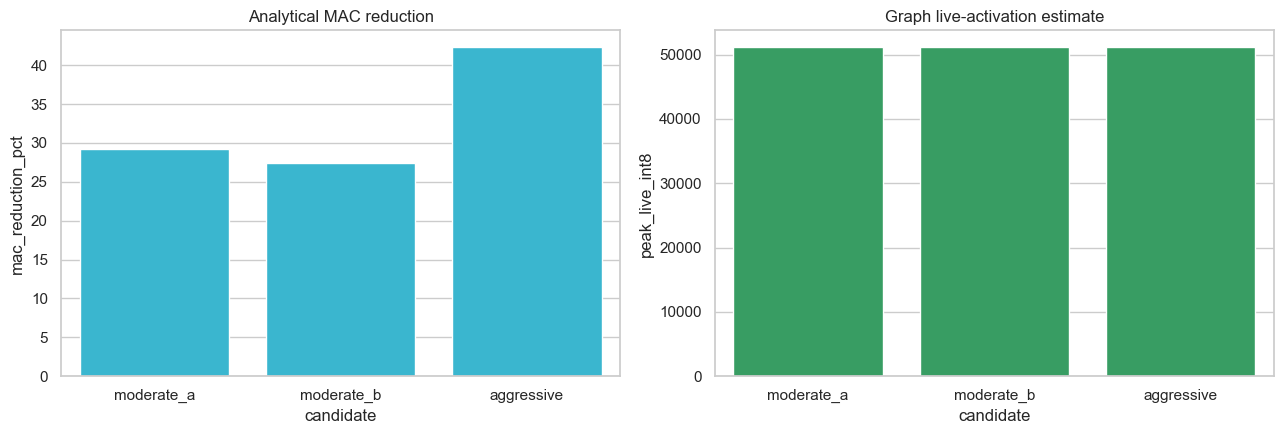

In [4]:
ranking_method = config['channel_pruning']['selected_initial_ranking']
schedules = {name: tuple(values) for name, values in config['channel_pruning']['schedules'].items()}
candidates, structural_rows = {}, []
for name, schedule in schedules.items():
    model = build_tiny_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], channel_schedule=schedule)
    transfer = transfer_structured_weights(parent, model, schedule, method=ranking_method)
    layers, liveness, profile = profile_model(model, training_batch_size=BATCH_SIZE)
    candidates[name] = model
    structural_rows.append({'candidate': name, 'schedule': '-'.join(map(str, schedule)), 'parameters': profile['parameters'], 'macs': profile['estimated_macs_batch1'], 'mac_reduction_pct': 100 * (1 - profile['estimated_macs_batch1'] / parent_profile['estimated_macs_batch1']), 'peak_live_int8': profile['peak_live_activation_int8_bytes_batch1_hypothetical']})
    (OUT / 'reports' / f'{name}_transfer.json').write_text(json.dumps(transfer, indent=2) + '\n')
structure = pd.DataFrame(structural_rows); structure.to_csv(OUT / 'reports/structural_screen.csv', index=False)
display(structure)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5)); sns.barplot(data=structure, x='candidate', y='mac_reduction_pct', ax=axes[0], color='#21C7E8'); sns.barplot(data=structure, x='candidate', y='peak_live_int8', ax=axes[1], color='#27AE60'); axes[0].set_title('Analytical MAC reduction'); axes[1].set_title('Graph live-activation estimate'); fig.tight_layout(); fig.savefig(OUT / 'figures/channel_structure.png', dpi=170, bbox_inches='tight'); plt.show()

## 4 · Equal-budget sensitivity screen

Each schedule receives the same three-epoch float recovery. Selection is performed twice without touching test labels: the quality track chooses the best validation candidate that passes recall/F1 gates, while the deployment track first enforces `MACs <= 2.5M` and then maximizes validation PR-AUC and F1.

In [5]:
screen_path = OUT / 'reports/validation_screen.csv'
screen_model_paths = {name: OUT / 'models' / f'{name}_screened.keras' for name in schedules}
REUSE_VALID_SCREEN = True
if REUSE_VALID_SCREEN and screen_path.is_file() and all(path.is_file() for path in screen_model_paths.values()):
    screen = pd.read_csv(screen_path).sort_values(['pr_auc', 'f1', 'macs'], ascending=[False, False, True])
    candidates = {name: tf.keras.models.load_model(path) for name, path in screen_model_paths.items()}
    print('Reused the completed equal-budget screen; set REUSE_VALID_SCREEN=False to retrain it.')
else:
    screen_rows = []
    for name, model in candidates.items():
        compile_model(model, learning_rate=float(config['training']['learning_rate']), label_smoothing=0.0)
        started = time.monotonic(); history = model.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['screening_epochs']), verbose=1)
        y_val, p_val = collect_predictions(model, val_ds)
        threshold = select_threshold(y_val, p_val, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))['threshold']
        metrics = classification_metrics(y_val, p_val, threshold)
        profile_row = structure.set_index('candidate').loc[name]
        metrics.update({'candidate': name, 'macs': int(profile_row.macs), 'peak_live_int8': int(profile_row.peak_live_int8), 'seconds': time.monotonic() - started})
        screen_rows.append(metrics); model.save(screen_model_paths[name])
    screen = pd.DataFrame(screen_rows).sort_values(['pr_auc', 'f1', 'macs'], ascending=[False, False, True])
    screen.to_csv(screen_path, index=False)
quality_eligible = screen[(screen.recall >= config['evaluation']['minimum_recall']) & (screen.f1 >= config['deployment_gate']['minimum_test_f1'])]
quality_pool = quality_eligible if len(quality_eligible) else screen
quality_winner_name = quality_pool.iloc[0].candidate
constraint_eligible = quality_eligible[quality_eligible.macs <= config['deployment_gate']['max_macs']]
assert len(constraint_eligible), 'No channel schedule satisfies both quality gates and the hard MAC constraint'
deployment_winner_name = constraint_eligible.iloc[0].candidate
track_specs = {
    'quality': {'candidate': quality_winner_name, 'purpose': 'best validation quality; diagnostic profiling'},
    'deployment': {'candidate': deployment_winner_name, 'purpose': 'best validation quality among MAC-valid candidates'},
}
for role, spec in track_specs.items(): spec['schedule'] = schedules[spec['candidate']]
display(screen[['candidate', 'macs', 'peak_live_int8', 'accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']])
print('Quality track:', quality_winner_name); print('Constraint-valid deployment track:', deployment_winner_name)

Reused the completed equal-budget screen; set REUSE_VALID_SCREEN=False to retrain it.


,candidate,macs,peak_live_int8,accuracy,precision,recall,specificity,f1,pr_auc
0,moderate_b,2901056,51200,0.675,0.630888,0.826087,0.527201,0.715412,0.767730
1,moderate_a,2824320,51200,0.666,0.617239,0.854398,0.481701,0.716709,0.760287
2,aggressive,2301840,51200,0.669,0.626060,0.821031,0.520277,0.710411,0.759372


Quality track: moderate_b
Constraint-valid deployment track: aggressive


## 5 · Full float fine-tuning of both selected schedules

The equal-budget screen now produces two explicitly named tracks. Each selected topology receives an independent lower-learning-rate float recovery with early stopping. This keeps the quality-oriented diagnostic result separate from the hard-constraint deployment result and isolates float recovery from subsequent QAT.

In [6]:
existing_summary_path = OUT / 'reports/experiment_summary.json'
existing_summary = json.loads(existing_summary_path.read_text()) if existing_summary_path.is_file() else {}
existing_quality = existing_summary.get('candidates', {}).get('quality', existing_summary)
legacy_finetuned_path = OUT / 'models/channel_pruned_finetuned_float.keras'
legacy_qat_path = OUT / 'models/channel_pruned_qat_float.keras'
REUSE_EXISTING_QUALITY_RECOVERY = True

def full_float_recovery(role, spec):
    candidate_name = spec['candidate']
    pre_metrics = screen.set_index('candidate').loc[candidate_name].to_dict()
    reuse_quality = REUSE_EXISTING_QUALITY_RECOVERY and role == 'quality' and existing_quality.get('selected_candidate') == candidate_name and legacy_finetuned_path.is_file() and legacy_qat_path.is_file()
    if reuse_quality:
        model = tf.keras.models.load_model(legacy_finetuned_path)
        model.save(OUT / 'models' / f'{candidate_name}_finetuned_float.keras')
        legacy_history = OUT / 'logs/full_float_history.csv'
        if legacy_history.is_file(): pd.read_csv(legacy_history).to_csv(OUT / 'logs' / f'{candidate_name}_full_float_history.csv', index=False)
        print(f'Reused completed float recovery for {candidate_name}.')
        return {'role': role, **spec, 'fine_tuned_float': model, 'screen_validation_metrics': pre_metrics, 'post_finetune_validation_metrics': existing_quality['post_finetune_validation_metrics'], 'float_training_seconds': existing_quality['float_training_seconds'], 'reused_existing_recovery': True}
    # Reload the screened checkpoint so each independently trained track begins from its own equal-budget result.
    model = tf.keras.models.load_model(OUT / 'models' / f'{candidate_name}_screened.keras')
    compile_model(model, learning_rate=float(config['training']['full_finetune_learning_rate']), label_smoothing=float(config['training']['label_smoothing']))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=int(config['training']['early_stopping_patience']), restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.3, patience=int(config['training']['reduce_lr_patience']), min_lr=1e-7),
    ]
    started = time.monotonic()
    history = model.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['full_finetune_epochs']), callbacks=callbacks, verbose=1)
    seconds = time.monotonic() - started
    y_val_float, p_val_float = collect_predictions(model, val_ds)
    float_threshold = select_threshold(y_val_float, p_val_float, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))['threshold']
    post_metrics = classification_metrics(y_val_float, p_val_float, float_threshold)
    model.save(OUT / 'models' / f'{candidate_name}_finetuned_float.keras')
    pd.DataFrame(history.history).to_csv(OUT / 'logs' / f'{candidate_name}_full_float_history.csv', index=False)
    return {'role': role, **spec, 'fine_tuned_float': model, 'screen_validation_metrics': pre_metrics, 'post_finetune_validation_metrics': post_metrics, 'float_training_seconds': seconds, 'reused_existing_recovery': False}

track_results = {role: full_float_recovery(role, spec) for role, spec in track_specs.items()}
recovery_rows = []
for role, result in track_results.items():
    recovery_rows.append({'track': role, 'candidate': result['candidate'], 'stage': 'after screen', **result['screen_validation_metrics']})
    recovery_rows.append({'track': role, 'candidate': result['candidate'], 'stage': 'after full float', **result['post_finetune_validation_metrics']})
display(pd.DataFrame(recovery_rows)[['track', 'candidate', 'stage', 'accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']])

Reused completed float recovery for moderate_b.
Epoch 1/8



  1/188 ━━━━━━━━━━━━━━━━━━━━ 19:01 6s/step - accuracy: 0.7188 - loss: 0.5306 - pr_auc: 0.8889 - precision: 0.8387 - recall: 0.6667 - roc_auc: 0.8297


  2/188 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.7031 - loss: 0.5426 - pr_auc: 0.8577 - precision: 0.7860 - recall: 0.6569 - roc_auc: 0.8063


  3/188 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.6962 - loss: 0.5503 - pr_auc: 0.8376 - precision: 0.7510 - recall: 0.6625 - roc_auc: 0.7946


  4/188 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.6930 - loss: 0.5540 - pr_auc: 0.8281 - precision: 0.7352 - recall: 0.6648 - roc_auc: 0.7890

...


29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step


,track,candidate,stage,accuracy,precision,recall,specificity,f1,pr_auc
0,quality,moderate_b,after screen,0.675,0.630888,0.826087,0.527201,0.715412,0.767730
1,quality,moderate_b,after full float,0.674,0.627170,0.840243,0.511375,0.718237,0.769928
2,deployment,aggressive,after screen,0.669,0.626060,0.821031,0.520277,0.710411,0.759372
3,deployment,aggressive,after full float,0.662,0.613984,0.852376,0.475767,0.713802,0.764515


## 6 · EMA-QAT recovery and clean topology restoration

Each selected topology—not the original width—is independently rebuilt with EMA fake quantizers. Learned tensors are copied back into ordinary dense Keras graphs before conversion so both deployable candidates contain only standard ESP-NN/TFLM operators.

In [7]:
def qat_recovery(result):
    candidate_name, schedule = result['candidate'], result['schedule']
    if result['reused_existing_recovery']:
        deployment_model = tf.keras.models.load_model(legacy_qat_path)
        deployment_model.save(OUT / 'models' / f'{candidate_name}_qat_float.keras')
        legacy_history = OUT / 'logs/qat_history.csv'
        if legacy_history.is_file(): pd.read_csv(legacy_history).to_csv(OUT / 'logs' / f'{candidate_name}_qat_history.csv', index=False)
        result['qat_training_seconds'] = existing_quality['qat_training_seconds']
        result['deployment_model'] = deployment_model
        print(f'Reused completed EMA-QAT recovery for {candidate_name}.')
        return result
    qat_model = build_qat_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], range_mode=config['qat']['range_mode'], ema_decay=float(config['qat']['ema_decay']), channel_schedule=schedule)
    copy_compatible_weights(result['fine_tuned_float'], qat_model)
    for layer in qat_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = False
    # Calibrate EMA observers before optimizer updates begin.
    for images, _ in train_ds.take(64): _ = qat_model(images, training=True)
    compile_model(qat_model, learning_rate=float(config['training']['qat_learning_rate']), label_smoothing=0.0)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=int(config['training']['early_stopping_patience']), restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.3, patience=int(config['training']['reduce_lr_patience']), min_lr=1e-7),
    ]
    started = time.monotonic()
    history = qat_model.fit(train_ds, validation_data=val_ds, epochs=int(config['training']['qat_recovery_epochs']), callbacks=callbacks, verbose=1)
    result['qat_training_seconds'] = time.monotonic() - started
    deployment_model = build_tiny_mobilenet_v1(input_shape=(*IMAGE_SIZE, 3), dropout=config['model']['dropout'], l2=config['model']['l2'], channel_schedule=schedule)
    strip = copy_qat_weights_to_float(qat_model, deployment_model); assert not strip['skipped_layers'], strip
    deployment_model.save(OUT / 'models' / f'{candidate_name}_qat_float.keras')
    pd.DataFrame(history.history).to_csv(OUT / 'logs' / f'{candidate_name}_qat_history.csv', index=False)
    result['deployment_model'] = deployment_model
    return result

track_results = {role: qat_recovery(result) for role, result in track_results.items()}

Reused completed EMA-QAT recovery for moderate_b.


Epoch 1/10


2026-09-17 18:20:16.619531: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  1/188 ━━━━━━━━━━━━━━━━━━━━ 26:50 9s/step - accuracy: 0.7031 - loss: 0.5209 - pr_auc: 0.8742 - precision: 0.8214 - recall: 0.6216 - roc_auc: 0.8318


  2/188 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.7148 - loss: 0.5144 - pr_auc: 0.8594 - precision: 0.8089 - recall: 0.6317 - roc_auc: 0.8330

...


184/188 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7205 - loss: 0.5472 - pr_auc: 0.7998 - precision: 0.7285 - recall: 0.7019 - roc_auc: 0.7995


185/188 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7205 - loss: 0.5472 - pr_auc: 0.7998 - precision: 0.7286 - recall: 0.7020 - roc_auc: 0.7995


186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7206 - loss: 0.5471 - pr_auc: 0.7998 - precision: 0.7286 - recall: 0.7020 - roc_auc: 0.7996


187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7206 - loss: 0.5471 - pr_auc: 0.7998 - precision: 0.7286 - recall: 0.7020 - roc_auc: 0.7996


188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.7237 - loss: 0.5451 - pr_auc: 0.8034 - precision: 0.7316 - recall: 0.7065 - roc_auc: 0.8015 - val_accuracy: 0.7030 - val_loss: 0.5841 - val_pr_auc: 0.7708 - val_precision: 0.6977 - val_recall: 0.7048 - val_roc_auc: 0.7655 - learning_rate: 1.0000e-05


## 7 · Independent locked tests, full-INT8 exports, resource audits, and gates

In [8]:
test_images = np.concatenate([np.asarray(images) for images, _ in test_ds])

def export_and_evaluate(result):
    candidate_name, deployment_model = result['candidate'], result['deployment_model']
    y_val, p_val = collect_predictions(deployment_model, val_ds)
    threshold = select_threshold(y_val, p_val, objective=config['evaluation']['threshold_objective'], minimum_recall=float(config['evaluation']['minimum_recall']))['threshold']
    final_validation_metrics = classification_metrics(y_val, p_val, threshold)
    y_test, p_float = collect_predictions(deployment_model, test_ds)
    float_metrics = classification_metrics(y_test, p_float, threshold)
    model_path = OUT / 'models' / f'vww_channel_{candidate_name}_qat_int8.tflite'
    convert_full_integer(deployment_model, representative_dataset(splits['train'], IMAGE_SIZE, int(config['export']['representative_samples']), seed), model_path)
    contract = inspect_tflite(model_path)
    p_int8 = run_tflite(model_path, test_images)
    int8_metrics = classification_metrics(y_test, p_int8, threshold)
    int8_metrics['expected_calibration_error_10_bins'] = expected_calibration_error(y_test, p_int8)
    int8_metrics['probability_mae_vs_float'] = float(np.mean(np.abs(p_int8 - p_float)))
    layers, liveness, model_profile = profile_model(deployment_model, training_batch_size=BATCH_SIZE)
    gates = {
        'full_int8': contract['input']['dtype'] == contract['output']['dtype'] == 'int8',
        'mac_target': model_profile['estimated_macs_batch1'] <= config['deployment_gate']['max_macs'],
        'recall': int8_metrics['recall'] >= config['deployment_gate']['minimum_test_recall'],
        'f1': int8_metrics['f1'] >= config['deployment_gate']['minimum_test_f1'],
        'parent_f1_retained': int8_metrics['f1'] >= parent_metrics['f1'] - config['deployment_gate']['maximum_f1_drop_from_parent'],
        'model_bytes': model_path.stat().st_size <= config['deployment_gate']['max_model_bytes'],
    }
    diagnostic_gates = {key: value for key, value in gates.items() if key != 'mac_target'}
    candidate_summary = {
        'role': result['role'], 'purpose': result['purpose'], 'selected_candidate': candidate_name,
        'ranking': ranking_method, 'channel_schedule': list(result['schedule']),
        'screen_validation_metrics': result['screen_validation_metrics'],
        'post_finetune_validation_metrics': result['post_finetune_validation_metrics'],
        'final_qat_validation_metrics': final_validation_metrics,
        'float_training_seconds': result['float_training_seconds'], 'qat_training_seconds': result['qat_training_seconds'],
        'reused_existing_recovery': result['reused_existing_recovery'],
        'threshold': threshold, 'float_test_metrics': float_metrics, 'int8_test_metrics': int8_metrics,
        'model_profile': model_profile, 'export': contract, 'model_path': str(model_path.relative_to(ROOT)),
        'gates': gates, 'ready_for_diagnostic_profile': all(diagnostic_gates.values()),
        'ready_for_device_profile': all(gates.values()),
        'model_sha256': hashlib.sha256(model_path.read_bytes()).hexdigest(),
    }
    (OUT / 'reports' / f'{candidate_name}_summary.json').write_text(json.dumps(candidate_summary, indent=2) + '\n')
    layers.to_csv(OUT / 'reports' / f'{candidate_name}_layer_profile.csv', index=False)
    liveness.to_csv(OUT / 'reports' / f'{candidate_name}_activation_liveness.csv', index=False)
    return candidate_summary

candidate_summaries = {role: export_and_evaluate(result) for role, result in track_results.items()}
deployment_summary = candidate_summaries['deployment']
summary = {
    'experiment': 'dependency_aware_channel_pruning', 'parent': parent_record,
    'selection_policy': {'quality': 'best validation PR-AUC after quality gates', 'deployment': 'hard MAC constraint, then best validation PR-AUC after quality gates', 'max_macs': config['deployment_gate']['max_macs']},
    'quality_candidate': candidate_summaries['quality']['selected_candidate'],
    'deployment_candidate': deployment_summary['selected_candidate'], 'candidates': candidate_summaries,
    # Backward-compatible deployment aliases for comparison scripts and older reports.
    **{key: deployment_summary[key] for key in ('selected_candidate', 'ranking', 'channel_schedule', 'screen_validation_metrics', 'post_finetune_validation_metrics', 'final_qat_validation_metrics', 'float_training_seconds', 'qat_training_seconds', 'threshold', 'float_test_metrics', 'int8_test_metrics', 'model_profile', 'export', 'gates', 'ready_for_device_profile', 'model_sha256')},
}
(OUT / 'reports/experiment_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
quality_table = [{'candidate': 'ema_qat_parent', **parent_metrics}]
quality_table += [{'candidate': item['selected_candidate'], **item['int8_test_metrics']} for item in candidate_summaries.values()]
display(pd.DataFrame(quality_table).set_index('candidate')[['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']])
gate_rows = [{'track': role, 'candidate': item['selected_candidate'], **item['gates'], 'diagnostic_profile': item['ready_for_diagnostic_profile'], 'promotion_profile': item['ready_for_device_profile']} for role, item in candidate_summaries.items()]
display(pd.DataFrame(gate_rows))

2026-09-17 18:24:55.823070: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



 1/32 ━━━━━━━━━━━━━━━━━━━━ 19s 637ms/step


 2/32 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step  


 3/32 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


 5/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

...

Saved artifact at '/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpq0skfuhb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 80, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4891817792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4891814272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4891814624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4891816912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4891818320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4891817616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4893984544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4893990528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4893987536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4893988944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4893995984: TensorSpec(shape=

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789644324.254998  634525 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789644324.255008  634525 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-09-17 18:25:24.255119: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpq0skfuhb
2026-09-17 18:25:24.257183: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-09-17 18:25:24.257190: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpq0skfuhb
2026-09-17 18:25:24.278469: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-09-1

fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-09-17 18:25:26.408093: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,accuracy,precision,recall,specificity,f1,pr_auc
candidate,,,,,,
ema_qat_parent,0.7020,0.656377,0.823649,0.584887,0.730561,0.790882
moderate_b,0.6660,0.612186,0.870540,0.469087,0.718855,0.780966
aggressive,0.6605,0.607244,0.871560,0.457311,0.715781,0.774510


,track,candidate,full_int8,mac_target,recall,f1,parent_f1_retained,model_bytes,diagnostic_profile,promotion_profile
0,quality,moderate_b,True,False,True,True,True,True,True,False
1,deployment,aggressive,True,True,True,True,True,True,True,True


## 8 · Physical ESP32-CAM handoff

Both models may be measured on the physical board, but their meanings differ. `moderate_b` is a diagnostic profile that maps channel reduction to real latency; only the constraint-valid `aggressive` track is eligible for promotion if all quality gates also pass.

In [9]:
SERIAL_PORT = '/dev/cu.YOUR_SERIAL_PORT'
profile_commands = {}
for role, item in candidate_summaries.items():
    profile_id = f"prune_channel_{item['selected_candidate']}"
    command = [str(ROOT / 'scripts/profile_esp32_model.sh'), str(ROOT / item['model_path']), '80', profile_id, SERIAL_PORT]
    profile_commands[role] = command
    eligibility = 'promotion-eligible' if item['ready_for_device_profile'] else 'diagnostic-only'
    print(f"{role} ({eligibility}): {' '.join(command)}")
RUN_DEVICE_PROFILES = False
if RUN_DEVICE_PROFILES:
    assert 'YOUR_SERIAL_PORT' not in SERIAL_PORT
    for role, command in profile_commands.items():
        assert candidate_summaries[role]['ready_for_diagnostic_profile'], f'{role} failed non-MAC quality/export gates'
        subprocess.run(command, cwd=ROOT, check=True)

quality (diagnostic-only): /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/scripts/profile_esp32_model.sh /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/pruning/channel/models/vww_channel_moderate_b_qat_int8.tflite 80 prune_channel_moderate_b /dev/cu.YOUR_SERIAL_PORT
deployment (promotion-eligible): /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/scripts/profile_esp32_model.sh /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/pruning/channel/models/vww_channel_aggressive_qat_int8.tflite 80 prune_channel_aggressive /dev/cu.YOUR_SERIAL_PORT
